In [554]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [555]:
%run src/common_functions.py

# Linear Regression

Linear Regression is one of the simplest and most fundamental forms of Machine Learning and has existed for centuries. The goal is to find a linear function that describes the relationship between a dependent variable $y$ and one or more independent variables (features) $x_i$, which can then be used to predict new values.

Hence, Linear Regression is a supervised Machine Learning technique that is particularly useful when the relationship between the target variable $y$ and its features can be reasonably approximated by a linear function.

It must be noted that we'll only consider Linear Regression for illustrative purposes as it has a closed-form solution that can be directly solved. This is called Ordinary Least Squares (OLS), which finds the exact weights for a given feature set and solution vector.

When comparing our Linear Regression GD output to sklearn, we will compare it to OLS as this is the implementation of sklearn's "Linear Regression".

### Single-Parameter Linear Regression

The simplest form of Linear Regression uses a single feature $x$ and is expressed as

$$
\hat{y} = wx + b
$$

where $w$ is the parameter that determines the slope of the line and $b$ is the intercept.

The same model can also be written using the more general coefficient notation:

$$
\hat{y} = \beta_0 + \beta_1 x_1
$$

Here, $\beta_0$ is the intercept and $\beta_1$ is the coefficient associated with the feature $x_1$.

The hat over $\hat{y}$ indicates that this is the model's prediction, rather than the actual observed value $y$.

For a single feature, Linear Regression can therefore be visualized as fitting a straight line through a set of data points in two-dimensional space.


We'll use some arbitrary data to best illustrate Linear Regression on a few selected datapoints.

In [556]:
data = pd.DataFrame(
    {
        "x_1": [2, 4, 8],
        "x_2": [1, 3, 5],
        "x_3": [10, 20, 30],
        "y":   [4, 8, 16]
    }
)

In [557]:
%run src/linear_regression_single.py

Plotting the data reveals a clear linear relationship between $x$ and $y$. To begin, we will consider only a single feature, $x_1$ and therefore use the simple linear regression model

$$
\hat{y} = wx_1 + b
$$

This allows us to first examine how the parameters $w$ and $b$ are optimized using Gradient Descent before extending the model to multiple features.

It becomes obvious that the optimal solution solution would be $y = 2x$

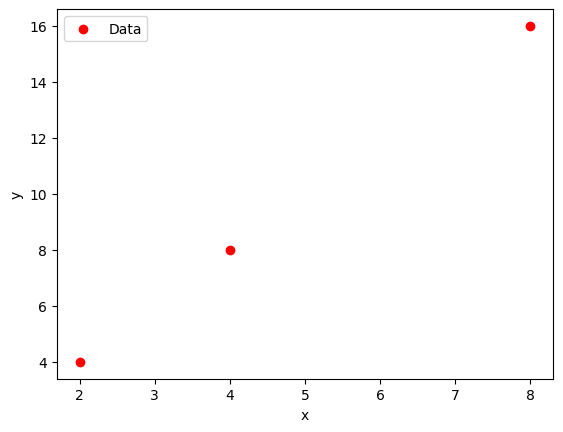

In [558]:
X = data["x_1"]
y = data["y"]

plot_data(X, y)

### Optimization function

The logic translates well from our previous example with $f(x) = x^2$. Here, we will optimize a different function.

A standard loss function that quantifies the errors, or residuals, between the actual datapoint values and the predicted values from our model is the Mean Squared Error (MSE):

$$

MSE(w, b) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2 = \frac{1}{n} \sum_{i=1}^n (y_i - (wx_{i,1} + b))^2

$$

where $y$ is the true value $f(x)$ and $\hat{y}$ is the model's prediction for the same $x$.

As we need to modify the parameters $b$ and $w$, we have to use partial derivatives of the MSE function. We can derive these partial derivatives using the chain rule of calculus.

$$
\frac{\partial MSE}{\partial b}(w,b) = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -1 = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))
$$

$$
\frac{\partial MSE}{\partial w}(w,b) = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -x_{1,i} = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))x_{1,i}
$$

Hence, when updating $b$, we will use $\frac{\partial MSE}{\partial b}$, and when updating $w$, we will use $\frac{\partial MSE}{\partial w}$.

Everything else stays the same, and we will update the two parameters according to the general Gradient Descent formula:

$$
x_{n+1} = x_n - \eta\nabla f(x_n)
$$

but for $b$:

$$
b_{n+1} = b_n - \eta \frac{\partial MSE}{\partial b}(w,b)
$$

and $w$:

$$
w_{n+1} = w_n - \eta \frac{\partial MSE}{\partial w}(w,b)
$$


For our example data, computing $w$ and $b$ using GD with a learning rate of $0.01$ and a max. of $500$ iterations, we get

$$
\hat{w} \approx 1.99, \hat{b} \approx 0.04
$$

which is already arbitrarly close to the optimal parameter values of $w = 2$, $b = 0$.

In [559]:
w_hat, b_hat = linear_regression_single(X, y, learning_rate=0.01, max_iters=500, tol=1e-6)

w_hat, b_hat

(np.float64(1.9937118366611004), np.float64(0.03743769780978872))

Plotting each individual update value of both $w$ and $b$ reveals their convergance towards both optimal values respectively.

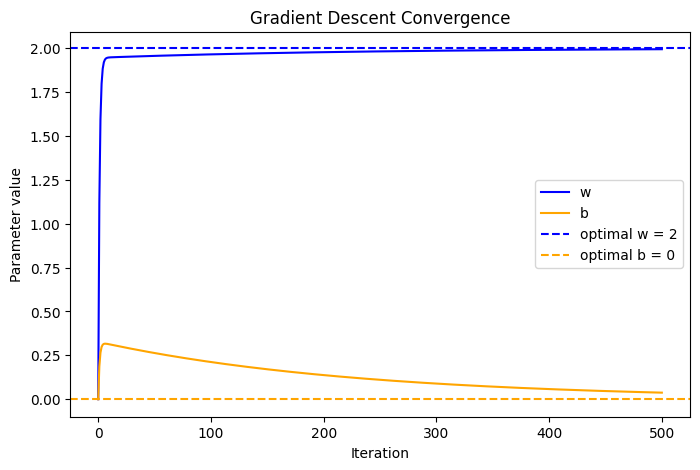

In [560]:
w_vals, b_vals = linear_regression_single(X, y, learning_rate=0.01, max_iters=500, tol=1e-6, history=True)

plot_optimal_parameters(w_vals, b_vals, optimal_w=2, optimal_b=0)

This plot illustrates how Gradient Descent iteratively adjusts the model parameters, gradually moving the linear function toward the configuration that minimizes the loss, i.e., the overall distance between the predictions and the actual data points.

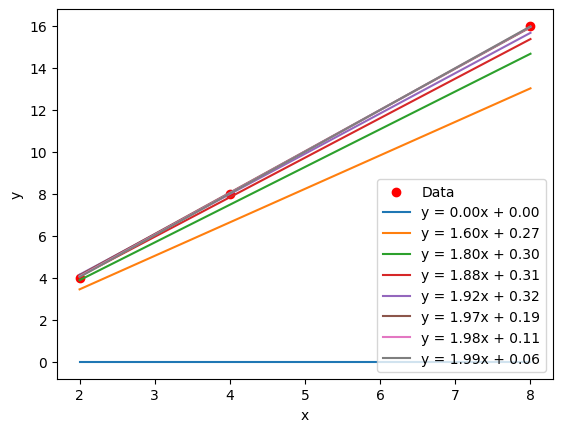

In [561]:
plot_gradient_progression_lr(X, y, w_vals, b_vals)

In [562]:
%run src/linear_regression.py

### Multiple Linear Regression

Until now, we have only looked at single-feature Linear Regression, approximating the value of one parameter $w$.

However, Linear Regression can also be applied to problems with multiple features or regressors $w_i$ with $|w| = m$, taking the form of

$$
\hat{y} = w_1x_1 + w_2x_2 + \dots + w_mx_m + b = b + \sum_{i=1}^m w_ix_i
$$

or equivalently

$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_mx_m = \beta_0 + \sum_{i=1}^m \beta_ix_i
$$

where $n$ is the total number of features/ regressors and each $w_i$ or $\beta_i$ represents the coefficient with feature $x_i$.

Each coefficient determines how strongly its corresponding feature contributes to the prediction, while holding other features constant.

Still, the same logic of Gradient Descent can be applied. But instead of just increasing the number of derivates of MSE by the number of new parameters $w_i$, we can use vectors and matrix multiplication for efficient computations.

We can also use vector notation :

$$
\hat{y} = \mathbf{x}^T\mathbf{w}+b
$$

with 
$$
\mathbf{x} = \begin{bmatrix} x_1 \\ \dots \\ x_m \end{bmatrix}
$$


$$
\mathbf{w} = \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix}
$$

where $\mathbf{x} \in \R^{m \times 1}$ denotes the feature values for a single observation, $\mathbf{w} \in \R^{m \times 1}$ is the parameter vector for all coefficients $w_i$.

For matrix multiplication, we need to transpose $\mathbf{x}$ s.t the number of columns of $\mathbf{x}$ equals the number of rows of $\mathbf{w}$, as we need a resulting scalar value for $\hat{y}$ (one value for our prediction).

Hence

$$
\hat{y} = x^Tw+b = \begin{bmatrix} x_1 \dots x_m \end{bmatrix} \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix} + b = x_1w_1 + \dots + x_mw_m + b = b + \sum_{i=1}^m x_iw_i
$$

We could just use this equation and iterate over all datapoints, calculting everything over and over again for different feature values.

However, using matrix notation for $\mathbf{x}$, we can immediately store all datapoints simultaneously and perform the same calculations all 'at once' (as libraries are heavily optimized towards vectorization and matrix multiplication).

Therefore, the final equation we will work with is denoted as

$$
\mathbf{\hat{y}} = \mathbf{X}\mathbf{w} + b
$$

where 

$$
\mathbf{X} = 
\begin{bmatrix}
  x_{1,1} & \dots & x_{1,m} \\
  \dots & \dots & \dots \\
  x_{n,1} & \dots & x_{n,m}
\end{bmatrix}
$$

with $\mathbf{X} \in \R^{n \times m}$, $\mathbf{w} \in \R^{m \times 1}$ and $b \in \R$.

Therefore,

$$
\mathbf{\hat{y}} = \mathbf{X}\mathbf{w} + b = \begin{bmatrix} x_{1,1}w_1 + \dots + x_{1,m}w_m + b \\ \dots \\  x_{n,1}w_1 + \dots + x_{n,m}w_m + b \end{bmatrix}
$$

with $\mathbf{\hat{y}} \in \R^{n \times 1}$.

But we still need our loss function and its derivative, the gradient, to calculate the update steps for gradient descent.

Hence we'll partially derive the Mean Squared Error (MSE) for both $w$ and $b$.

We define for a single row and per feature value:
$$
L_{w,b} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2 =  \frac{1}{n} \sum_{i=1}^n (y_i - (wx_{1,i}+b))^2
$$

and therefore
$$
\nabla L_b = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial b} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -1 = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))
$$

$$
\nabla L_w = \frac{1}{n} \sum_{i=1}^n 2(y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - (wx_{1,i} + b)] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * \frac{\partial}{\partial w} [y_i - wx_{1,i} - b] = \frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) * -x_{1,i} = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))x_{1,i}
$$

Lets define $\mathbf{y} \in \R^{n \times 1}$ as
$$
\mathbf{y} = \begin{bmatrix} y_1 \\ \dots \\ y_n \end{bmatrix}
$$

and the error as $\mathbf{e} \in \R^{n \times 1}$ as

$$
\mathbf{e} = \mathbf{y} - \mathbf{\hat{y}} = \mathbf{y} - (\mathbf{X}\mathbf{w}+b) = \begin{bmatrix} y_1 \\ \dots \\ y_n \end{bmatrix} - \begin{bmatrix} x_{1,1}w_1 + \dots + x_{1,m}w_m + b \\ \dots \\  x_{n,1}w_1 + \dots + x_{n,m}w_m + b \end{bmatrix} = \begin{bmatrix} y_1 - (x_{1,1}w_1 + \dots + x_{1,m}w_m + b) \\ \dots \\  y_n - (x_{n,1}w_1 + \dots + x_{n,m}w_m + b) \end{bmatrix} = \begin{bmatrix} e_1 \\ \dots \\ e_n \end{bmatrix}
$$

Now we can rewrite the derived gradients as

$$
\nabla L_w = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b))x_{1,i} = -\frac{2}{n}X^Te
$$
$$
\nabla L_b = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_{1,i} + b)) = -\frac{2}{n}e
$$

We need to calcuate $\mathbf{X}^T\mathbf{e}$ instead of $\mathbf{eX}$ due to matrix multiplication rules as $\mathbf{X} \in \R^{n \times m}$ and $\mathbf{e} \in \R^{n \times 1}$.

Therefore,
$$
-\frac{2}{n}\mathbf{X}^T\mathbf{e} = -\frac{2}{n} 
\begin{bmatrix}
  x_{1,1} & \dots & x_{n,1} \\
  \dots & \dots & \dots \\
  x_{1,m} & \dots & x_{n,m}
\end{bmatrix} 
\begin{bmatrix} e_1 \\ \dots \\ e_n \end{bmatrix} = -\frac{2}{n} \begin{bmatrix} x_{1,1}e_1 + \dots + x_{n,1}e_n\\ \dots \\ x_{1,m}e_1 + \dots + x_{n,m}e_n \end{bmatrix} = \begin{bmatrix} -\frac{2}{n} (x_{1,1}e_1 + \dots + x_{n,1}e_n) \\ \dots \\ -\frac{2}{n} (x_{1,m}e_1 + \dots + x_{n,m}e_n) \end{bmatrix} = \begin{bmatrix} -\frac{2}{n} \sum_{i=1}^n x_{i,1}e_i \\ \dots \\ -\frac{2}{n} \sum_{i=1}^n x_{i,m}e_i \end{bmatrix}
$$

and 

$$
-\frac{2}{n}\mathbf{e} = -\frac{2}{n}\mathbf{1}^T\mathbf{e} = -\frac{2}{n} \begin{bmatrix} 1 & \dots & 1 \end{bmatrix} \begin{bmatrix} e_1 \\ \dots \\ e_n \end{bmatrix} = -\frac{2}{n} \begin{bmatrix} 1e_1 + \dots + 1e_n \end{bmatrix} = -\frac{2}{n} \sum_{i=1}^n e_i
$$

Those are our final gradient vector and scalar.

Plugging these into Gradient Descent yields

$$
b_{k+1} = b_k - \eta \nabla L_b = b_n - \eta (-\frac{2}{n} \sum_{i=1}^n e_i)
$$
$$
w_{k+1} = w_k - \eta \nabla L_w = \begin{bmatrix} w_1 \\ \dots \\ w_m \end{bmatrix} - \eta (\begin{bmatrix} -\frac{2}{n} \sum_{i=1}^n x_{i,1}e_i \\ \dots \\ -\frac{2}{n} \sum_{i=1}^n x_{i,m}e_i \end{bmatrix})
$$

In [563]:
X = data[["x_1", "x_2"]]
y = data["y"]

b, w = linear_regression(X, y, learning_rate=0.01, max_iters=50_000, tol=1e-6)

sklearn_lr = LinearRegression()
sklearn_lr.fit(X, y)

display(compare_lr_to_sklearn(w, b, sklearn_lr))

print(f"Within the exact solution by 10^-5 tolerance: {np.allclose(w, sklearn_lr.coef_, rtol=0, atol=1e-5)}")
print(f"Within the exact solution by 10^-6 tolerance: {np.allclose(w, sklearn_lr.coef_, rtol=0, atol=1e-6)}")

LinearRegression  Sklearn LinearRegression
parameter name                                            
weight    w_0       1.999996e+00              2.000000e+00
          w_1       6.231275e-06              1.541800e-15
intercept b         2.930284e-07              3.552714e-15

Within the exact solution by 10^-5 tolerance: True
Within the exact solution by 10^-6 tolerance: False


In [564]:
X = data[["x_1", "x_2", "x_3"]]
y = data["y"]


b, w = linear_regression(X, y, learning_rate=0.001, max_iters=500_000, tol=1e-10)


sklearn_lr = LinearRegression()
sklearn_lr.fit(X, y)

display(compare_lr_to_sklearn(w, b, sklearn_lr))

print(f"Within the exact solution by 10^-9 tolerance: {np.allclose(w, sklearn_lr.coef_, rtol=0, atol=1e-9)}")
print(f"Within the exact solution by 10^-10 tolerance: {np.allclose(w, sklearn_lr.coef_, rtol=0, atol=1e-10)}")

LinearRegression  Sklearn LinearRegression
parameter name                                            
weight    w_0       2.000000e+00              2.000000e+00
          w_1       3.728220e-10              7.379556e-17
          w_2       4.696804e-11              3.689778e-16
intercept b        -3.634300e-10             -3.552714e-15

Within the exact solution by 10^-9 tolerance: True
Within the exact solution by 10^-10 tolerance: False


### Divergence for increased learning rate $\eta$

If we increase the learning rate $\eta$ from $0.001$ to $0.01$, gradient descent diverges, s.t. all parameters are eventually considered "infinite".

Why does this happen?

In the 1-d case with one feature, we have

$$
\hat{y} = wx_i  +b 
$$

as well as 

$$
L(w,b) = \frac{1}{n} \sum_{i=1}^n (y_i - (wx_i + b))^2
$$

Lets focus on $w$, treating $b$ as fixed.

We also know
$$
\frac{\partial L}{\partial w} = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_i + b))x_i = -\frac{2}{n} \sum_{i=1}^n (y_i - wx_i - b)x_i = -\frac{2}{n} \sum_{i=1}^n x_iy_i - wx^2_i - x_ib
$$

To find out which learning rate $\eta$ guarantees convergance, we need to look at the curvature with the second derivative:

$$
\frac{\partial^2 L}{\partial w^2} = -\frac{2}{n} \sum_{i=1}^n -x^2_i = \frac{2}{n} \sum_{i=1}^n x^2_i
$$

Thats called the hessian $\mathbf{H}$ matrix of $L_w$ in 1-d.

In general, the hessian matrix is defined as

$$
\mathbf{H} = 
\begin{bmatrix}
  \frac{\partial^2f}{\partial x_1 \partial x_1}(x) & \dots & \frac{\partial^2f}{\partial x_1 \partial x_m}(x) \\
  \dots & \dots & \dots \\
  \frac{\partial^2f}{\partial x_m \partial x_1}(x) & \dots & \frac{\partial^2f}{\partial x_m \partial x_m}(x)
\end{bmatrix}
$$

and contains all the second derivatives of $f$ with respect to all its parameters $x_i$ where $m$ is the total number of parameters.

For our 1-d, 1-feature example with $m=1$,

$$
\mathbf{H} = 
\begin{bmatrix}
  \frac{\partial^2 L}{\partial w^2}
\end{bmatrix}
= \frac{2}{n} \sum_{i=1}^n x^2_i
$$

Usually, we would take the eigenvectors $\lambda_i$ of $\mathbf{H}$ to do the following inequality calculation. But since we have $\mathbf{H} \in \R^{1 \times 1}$, the only eigenvector is just the second derivative itself.

Lets look at the convergence condition from GD again

$$
w_{k+1} = w_k - \eta \nabla L_w
$$

The hessian matrix tells us how strongly the slope increases (second derivative). As MSE is a quadratic function $(y_i - (wx_i + b))^2$, the slope gets bigger the farther its away from the bottom or min $w^* = 0$.

Or mathematically for $w^*$
$$
\nabla L_w = \frac{dL}{dw} = 0
$$

So we can calculate the current slope $\frac{dL}{dw}$ by multiplying the curvature and distance from the minimum, which is $\mathbf{H}(w - w^*)$

$$
\frac{dL}{dw} = \mathbf{H}(w - w^*)
$$

Therefore,
$$
w_{k+1} = w_k - \eta \nabla L_w = w_k - \eta \mathbf{H}(w_k - w^*)
$$

for $e_k = w_k - w^*$, we get
$$
w_{k+1} - w^* = w_k - \eta \mathbf{H}(w_k - w^*) - w^* \implies e_{k+1} = (e_k) (-\eta \mathbf{H}(e_k)) = (1 - \eta\mathbf{H})e_k
$$

Lastly, we solve the following inequality $|e_{k+1}| < |e_{k}|$
$$
|e_{k+1}| < |e_{k}| = |(1 - \eta\mathbf{H})e_k| < |e_k| = |1 - \eta\mathbf{H}| < |1|
$$

For absolute values, it must hold that
$$
|1 - \eta\mathbf{H}| < |1| = -1 < 1 - \eta\mathbf{H} < 1 = \eta\mathbf{H} < 2 = \eta < \frac{2}{\mathbf{H}}
$$

because if $|1 - \eta\mathbf{H}| < |1|$, the non-absolute values must lie inbetween -1 and 1.

For conclusion, in our 1-d case, the learning rate $\eta$ must be smaller than $\frac{2}{\mathbf{H}}$ for convergance.


For an arbitrary number of features $m$, we generalize the formula above.

We already know that

$$
\nabla L_w = -\frac{2}{n}\mathbf{X}^Te 
$$
where $e = y - (\mathbf{X}w + b) = y - \mathbf{X}w - b$

Hence
$$
\nabla L_w  = -\frac{2}{n}\mathbf{X}^T (y - \mathbf{X}w - b) = -\frac{2}{n}\mathbf{X}^Ty - (-\frac{2}{n}\mathbf{X}^T\mathbf{X}w) - (-\frac{2}{n}\mathbf{X}^Tb) = -\frac{2}{n}\mathbf{X}^Ty + \frac{2}{n}\mathbf{X}^T\mathbf{X}w + \frac{2}{n}\mathbf{X}^Tb
$$

Notice that both $y$ and $b$ are constants here. So computing the second derivative of the gradient with respect to $w$ leads to
$$
\frac{\partial^2 L}{\partial w^2} = \frac{\partial \nabla L}{\partial w} = \frac{2}{n}\mathbf{X}^T\mathbf{X}
$$
which is the hessian matrix of $L_w$
$$
\mathbf{H} = \frac{2}{n}\mathbf{X}^T\mathbf{X}
$$

Since our matrix $\mathbf{H}$ is now not a single scalar but a matrix of type $\mathbf{H} \in \R^{n \times m}$, we cant just say $\eta < \frac{2}{\mathbf{H}}$.

Instead, we'll use its eigenvalues $\lambda_i$ as we now have not 1 dimensions but $m$ and all eigenvalues $\lambda_1 \dots \lambda_m$ tell use the curvature along all those dimensions/ directions.

We specifically want to look at the largest eigenvalue $\lambda_max$ which has the steepest curvature direction which puts the strictest limit on our learning rate.


Hence $\eta$ must fullfil 
$$
\eta < \frac{2}{\lambda_{max}(\mathbf{H})} \Leftrightarrow \eta < \frac{n}{\lambda_{max}(\mathbf{X^TX})}
$$


Let's calculate it for our LR example with
$$
\mathbf{X} = 
\begin{bmatrix}
  2 & 1 & 10 \\
  4 & 3 & 20 \\
  8 & 5 & 30
\end{bmatrix}
$$

$$
\mathbf{X^TX} =
\begin{bmatrix}
  2 & 4 & 8 \\
  1 & 3 & 5 \\
  10 & 20 & 30
\end{bmatrix}
\begin{bmatrix}
  2 & 1 & 10 \\
  4 & 3 & 20 \\
  8 & 5 & 30
\end{bmatrix}
=
\begin{bmatrix}
  84 & 54 & 340 \\
  54 & 35 & 220 \\
  340 & 220 & 1400
\end{bmatrix}
$$

The eigenvalues of $\mathbf{X^TX}$ are  $\lambda_1 = 1517.27075$,  $\lambda_2 = 1.56028363$ and $\lambda_3 =  0.168963677$, hence
$$
\lambda_{max}(\mathbf{H}) = \lambda_1 = 1517.27075
$$

for $n = 3$, we get the convergance condition
$$
\eta < \frac{n}{\lambda_{max}(\mathbf{H})} = \eta < \frac{3}{1517.27075} = \eta < 0.002
$$



In [565]:
b, w = linear_regression(X, y, learning_rate=0.01, max_iters=500_000, tol=1e-10, divergance_check=True)

AssertionError: Gradient Descent will diverge with learning rate 0.01 as it can not be greater or equal to 0.001977

### Divergance Solution

How could we prevent divergence without calculating the maximum value of $\eta$, while also assigning meaningful values to our coefficients?

Feature standardization is a common step in a preprocessing pipeline for machine learning problems.

While there are many variants, such as z-score standardization, min-max scaling or L1/L2 normalization, all of them focus on roughly the same idea: making features comparable with each other by scaling their value ranges to certain upper and lower bounds.

For this, we'll use z-score standardization:

$$
z = \frac{x-\mu}{\sigma}
$$

where $x$ is our data, $\mu$ is the mean of the data $\overline{x} = \frac{1}{n}\sum_{i=1}^n x_i $ and $\sigma$ is the standard deviation of the data $\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^n (x_i - \overline{x})^2}$

This centers each feature's values around $0$ and must be done on a per feature basis.

Hence our data 
$$
\mathbf{X} = 
\begin{bmatrix}
  2 & 1 & 10 \\
  4 & 3 & 20 \\
  8 & 5 & 30
\end{bmatrix}
$$

becomes

$$
\mathbf{X_{scaled}} = 
\begin{bmatrix}
  -1.06904497 & -1.22474487 & -1.22474487 \\
  -0.26726124 & 0 & 0 \\
  1.33630621 & 1.22474487 & 1.22474487
\end{bmatrix}
$$

What's the maximum learning rate now? When will it diverge?

First, we need to understand how eigenvalues are calculated.

We solve
$$
det(\mathbf{X^TX} - \lambda \mathbf{I}) = 0
$$
to calculate said eigenvalues, where $\mathbf{I}$ is the identity matrix that has all $0s$ but $1s$ on the diagonal.

Hence
$$
\lambda \mathbf{I} = 
\begin{bmatrix}
  \lambda & 0 & \dots & 0 \\
  0 & \lambda & \dots & 0\\
  \dots & \dots & \dots & \dots\\
  0 & 0 & \dots & \lambda
\end{bmatrix}
$$
and
$$
\mathbf{X^TX} - \lambda \mathbf{I} = 
\begin{bmatrix}
  x_{1,1}-\lambda & x_{1,2} & \dots & x_{1,m} \\
  x_{2,1} & x_{2,2}-\lambda & \dots & x_{2,m} \\
  \dots & \dots & \dots & \dots \\
  x_{m,1} & x_{m,2} & \dots & x_{m,m} -\lambda
\end{bmatrix}
$$

as $\mathbf{X^TX} \in \R^{m \times m}$ as $\mathbf{X} \in \R^{n \times m}$

The eigenvalues are the solution to the preceding equation
$$
det(\mathbf{X^TX} - \lambda \mathbf{I}) = 
det(
\begin{bmatrix}
  x_{1,1}-\lambda & x_{1,2} & \dots & x_{1,m} \\
  x_{2,1} & x_{2,2}-\lambda & \dots & x_{2,m} \\
  \dots & \dots & \dots & \dots \\
  x_{m,1} & x_{m,2} & \dots & x_{m,m} -\lambda
\end{bmatrix}
)
= 0
$$

which produces a polynomial of degree $m$ with $m$ solutions. These solutions $\lambda_i$ are the $m$ eigenvalues of $\mathbf{X^TX}$.

However, these cannot be easily solved manually for high degrees and are usually computed algorithmically.

What's crucial to understand here is that the eigenvalues depend on the values of the features themselves.

For our scaled matrix $\mathbf{X}_{scaled}$, the largest eigenvalue is $\lambda_{max} \approx 8.9$, allowing a learning rate of up to $\eta < 0.336$ before divergence, representing an increase by a factor of 168.



In [566]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

b, w = linear_regression(pd.DataFrame(X_scaled), y, learning_rate=0.01, max_iters=500_000, tol=1e-10, divergance_check=True)

sklearn_lr = LinearRegression()
sklearn_lr.fit(X_scaled, y)

display(compare_lr_to_sklearn(w, b, sklearn_lr))

print(f"Within the exact solution by 10^-8 tolerance: {np.allclose(w, sklearn_lr.coef_, rtol=0, atol=1e-8)}")
print(f"Within the exact solution by 10^-9 tolerance: {np.allclose(w, sklearn_lr.coef_, rtol=0, atol=1e-9)}")


LinearRegression  Sklearn LinearRegression
parameter name                                            
weight    w_0       4.988877e+00              4.988877e+00
          w_1       8.462451e-10              2.610999e-16
          w_2       8.462451e-10              2.610999e-16
intercept b         9.333333e+00              9.333333e+00

Within the exact solution by 10^-8 tolerance: True
Within the exact solution by 10^-9 tolerance: False
